#### This notebook reproduces Figure S8 in "Exceeding Human Heat Tolerance: Global Projections for a Warming, Aging World" by Kong et al.

In [1]:
"""
import python packages
please install required packages before running this notebook
"""
import xarray as xr
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
%matplotlib inline
%config InlineBackend.figure_format = "retina"

ERROR 1: PROJ: proj_create_from_database: Open of /home/kong97/.conda/envs/geo_env/share/proj failed


In [2]:
# directory to data; you might want to change it to your own directory
path='../data/'
# read in annual uncompensable heat hours
tas_clima=xr.open_dataset(path+'climatological_annual_mean_temperature.nc').t2m
# read in land mask file
landmask=xr.open_dataset(path+'ERA5_land_mask.nc').mask

In [3]:
# create colormap
colors=np.array([[171,217,233],
                 [255,255,191],
                 [253,174,97]])
cmap=mpl.colors.ListedColormap(colors/255.)

In [4]:
# function to plot each individual panel of the figure
def subplot(data,axis,norm,cmap):
    LON,LAT=np.meshgrid(data.lon.values,data.lat.values)
    g=axis.pcolormesh(LON, LAT,data.where(landmask==0),
                      transform=ccrs.PlateCarree(),
                      cmap=cmap,norm=norm,rasterized=True) 
    axis.coastlines(linewidth=0.5,resolution='50m') # add coastlines
    axis.set_title('')
    axis.set_extent([-169.999,189.999,-60,75]) # set extent of the map to exclude high latitudes
    return g

# function to plot the whole figure
def plot(data):
    fig = plt.figure(figsize=[8,6]) # create figure
    levels=[-100,5,20,100] # set levels for color scale
    norm=mpl.colors.BoundaryNorm(levels,ncolors=len(levels)-1,extend='neither')
    clabel='Annual average temperature (°C)' # colorbar label
    
    axis=fig.add_subplot(111,projection=ccrs.Robinson(central_longitude=10))
    g=subplot(data,axis,norm,cmap)

    cb=fig.colorbar(g,ax=axis,orientation='horizontal',pad=0.02,shrink=0.75,fraction=.08,aspect=70,ticks=[5,20])
    tick_labels=['5','20']
    cb.set_ticklabels(tick_labels)
    cb.set_label(label=clabel, size=16)
    cb.ax.tick_params(labelsize=14)

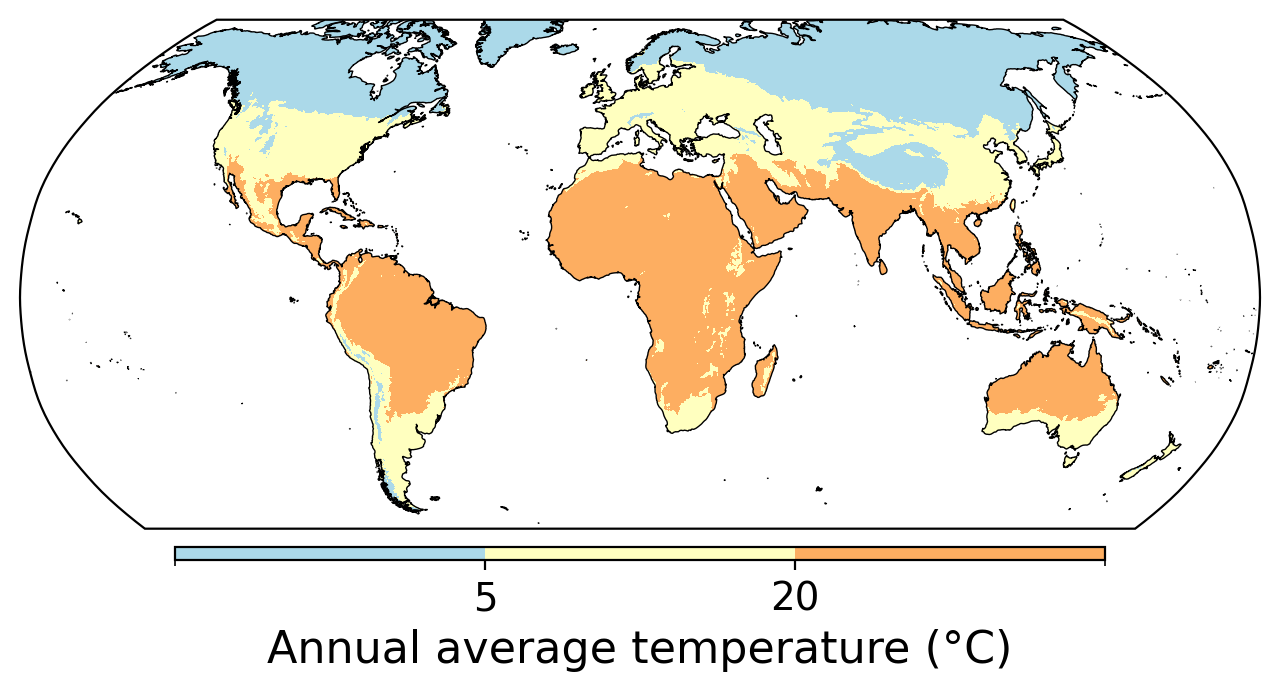

In [5]:
plot(tas_clima-273.15)

**Fig. S8** Annual average temperature during 1996–2025. We raise heat compensability thresholds by 0.5 oC in warm regions (annual average temperature > 20 oC) and lower thresholds by 0.5 oC in cold regions (<5 oC) to test the effects of regionally varying heat acclimatization.